**Code pipeline for Herbal Palnt detection and recognition**

**Mount the drive**

In [1]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Unzipping the images and storing them in a folder on the drive**

In [ ]:
!ls /content/dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!unzip "/content/drive/MyDrive/Computer Vision/Plant-Recognition.v1.zip" -d "/content/drive/MyDrive/Computer-Vision/dataset"

Archive:  /content/drive/MyDrive/Computer Vision/Plant-Recognition.v1.zip
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/train/images/VID_20260408_171126_0026_jpg.rf.74110e023cb9bd479fb55badf793a058.jpg  
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/train/images/VID_20260408_174323_0028_jpg.rf.f1a5ade2e5123d957088b03eefb4d639.jpg  
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/train/images/VID_20260408_171126_0032_jpg.rf.1de7e1540ce4d4ee0a946500c7cab80a.jpg  
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/train/images/VID_20260408_174323_0079_jpg.rf.2c5e709e28da260b30eaa74d167955e8.jpg  
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/train/images/VID_20260408_174524_0040_jpg.rf.382c3f71539a3b7b59018454f90b4797.jpg  
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/train/images/VID_20260408_173112_0053_jpg.rf.85d65c92553824ae63cd94968378a108.jpg  
 extracting: /content/drive/MyDrive/Computer-Vision/dataset/tr

**Perfoming image Enhancements using Guassian Blur and CLAHE**

**Gaussian Blur**

In [ ]:
import cv2
import os

# Input folders
input_folders = {
    'train': '/content/drive/MyDrive/Computer-Vision/dataset/train/images',
    'valid': '/content/drive/MyDrive/Computer-Vision/dataset/valid/images',
    'test': '/content/drive/MyDrive/Computer-Vision/dataset/test/images'
}

# Output base folder
output_base = '/content/drive/MyDrive/Computer-Vision/gaussian_blur_dataset'

for split, folder in input_folders.items():

    # Create output folder
    output_folder = os.path.join(output_base, split, 'images')
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(folder):

        input_path = os.path.join(folder, filename)

        image = cv2.imread(input_path)

        if image is None:
            continue

        # Apply Gaussian Blur
        blurred = cv2.GaussianBlur(image, (3,3), 0)

        # Save processed image
        output_path = os.path.join(output_folder, filename)

        cv2.imwrite(output_path, blurred)

print("Gaussian Blur preprocessing completed.")

Gaussian Blur preprocessing completed.


In [ ]:
!ls "/content/drive/MyDrive/Computer-Vision/gaussian_blur_dataset"

test  train  valid


**CLAHE Enhancement**

In [ ]:
import cv2
import os

# Input folders (Gaussian blurred images)
input_folders = {
    'train': '/content/drive/MyDrive/Computer-Vision/gaussian_blur_dataset/train/images',
    'valid': '/content/drive/MyDrive/Computer-Vision/gaussian_blur_dataset/valid/images',
    'test': '/content/drive/MyDrive/Computer-Vision/gaussian_blur_dataset/test/images'
}

# Output base folder
output_base = '/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset'

for split, folder in input_folders.items():

    # Create output folder
    output_folder = os.path.join(output_base, split, 'images')
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(folder):

        input_path = os.path.join(folder, filename)

        image = cv2.imread(input_path)

        if image is None:
            continue

        # Convert to LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

        l, a, b = cv2.split(lab)

        # Apply CLAHE
        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        )

        cl = clahe.apply(l)

        # Merge channels
        enhanced = cv2.merge((cl, a, b))

        # Convert back to BGR
        final = cv2.cvtColor(
            enhanced,
            cv2.COLOR_LAB2BGR
        )

        # Save enhanced image
        output_path = os.path.join(output_folder, filename)

        cv2.imwrite(output_path, final)

print("CLAHE enhancement completed.")

CLAHE enhancement completed.


**copy labels and data,yam from the zipped file to the drive**

***Copy Labels***

In [ ]:
import shutil
import os

# Original dataset path
original_base = '/content/drive/MyDrive/Computer-Vision/dataset'

# Final enhanced dataset path
enhanced_base = '/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset'

splits = ['train', 'valid', 'test']

for split in splits:

    src_labels = os.path.join(original_base, split, 'labels')

    dst_labels = os.path.join(enhanced_base, split, 'labels')

    shutil.copytree(src_labels, dst_labels, dirs_exist_ok=True)

print("Labels copied successfully.")

Labels copied successfully.


**Copy data.yaml**

In [ ]:
import shutil

src = '/content/drive/MyDrive/Computer-Vision/dataset/data.yaml'

dst = '/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset/data.yaml'

shutil.copy(src, dst)

print("data.yaml copied successfully.")

data.yaml copied successfully.


In [ ]:
!ls "/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset"

data.yaml  test  train	valid


**Feature extraction(edges, texture, shape)**

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 157MB/s]


Saved successfully at:
/content/drive/MyDrive/Computer-Vision/Final_Results/Figure_3_4_CNN_Feature_Maps.png


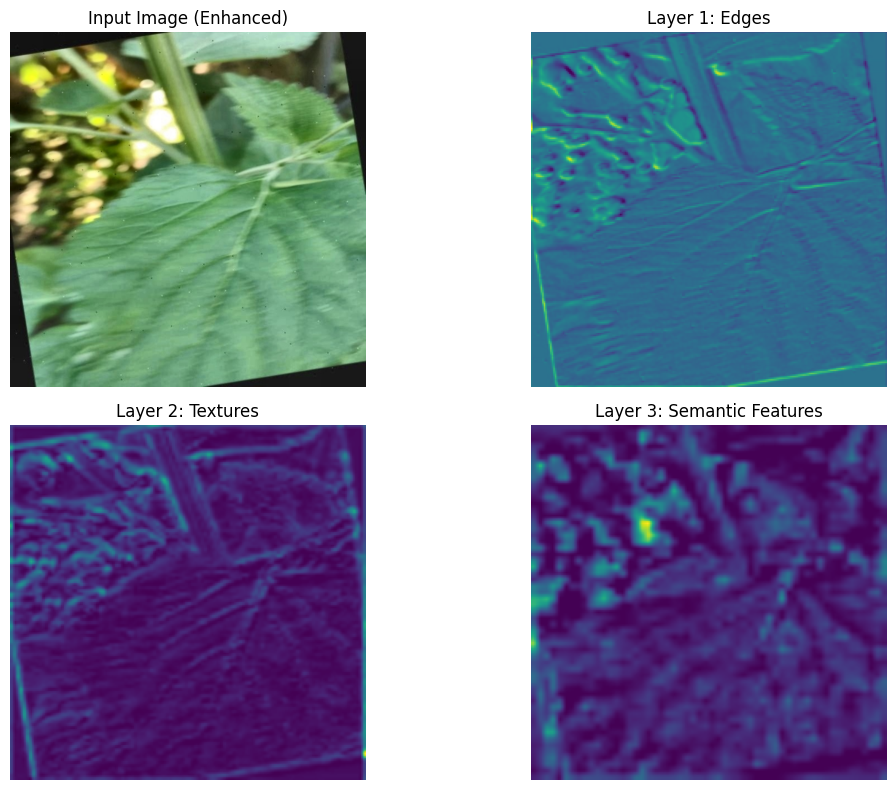

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import cv2

# =========================================================
# 1. LOAD IMAGE
# =========================================================
img_dir = "/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset/train/images"

img_name = os.listdir(img_dir)[0]
img_path = os.path.join(img_dir, img_name)

img = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img_tensor = transform(img).unsqueeze(0)

# =========================================================
# 2. LOAD VGG16
# =========================================================
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
model.eval()

# =========================================================
# 3. HOOK FEATURE MAPS
# =========================================================
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output)

layers = [0, 5, 10]

for i in layers:
    model[i].register_forward_hook(hook_fn)

# =========================================================
# 4. FORWARD PASS
# =========================================================
with torch.no_grad():
    _ = model(img_tensor)

# =========================================================
# 5. SAFE RESIZE FUNCTION (KEY FIX)
# =========================================================
def resize_map(fm, size=(224,224)):
    return cv2.resize(fm, size)

# =========================================================
# 6. BUILD FIGURE
# =========================================================
def build_figure(fmaps, img):

    fig = plt.figure(figsize=(12, 8))

    # -------------------------
    # INPUT IMAGE
    # -------------------------
    ax1 = plt.subplot(2, 2, 1)
    ax1.imshow(img)
    ax1.set_title("Input Image (Enhanced)")
    ax1.axis("off")

    # -------------------------
    # FEATURE MAP PLOTTER
    # -------------------------
    def plot_maps(fmap, title, position):

        fmap = fmap[0].detach().cpu()

        if len(fmap.shape) == 4:
            fmap = fmap[0]

        count = 0
        combined = np.zeros((224,224))

        for i in range(fmap.shape[0]):

            fm = fmap[i]

            if len(fm.shape) != 2:
                continue

            fm = fm.numpy()

            # normalize
            fm = (fm - fm.min()) / (fm.max() + 1e-8)

            # FIX: resize BEFORE adding
            fm = resize_map(fm, (224,224))

            combined += fm

            count += 1
            if count == 5:
                break

        combined = combined / max(count, 1)

        ax = plt.subplot(2, 2, position)
        ax.imshow(combined, cmap="viridis")
        ax.set_title(title)
        ax.axis("off")

    # -------------------------
    # LAYERS
    # -------------------------
    plot_maps(feature_maps[0], "Layer 1: Edges", 2)
    plot_maps(feature_maps[1], "Layer 2: Textures", 3)
    plot_maps(feature_maps[2], "Layer 3: Semantic Features", 4)

    plt.tight_layout()

    return fig

# =========================================================
# 7. CREATE FIGURE
# =========================================================
fig = build_figure(feature_maps, img)

# =========================================================
# 8. SAVE PNG (OVERLEAF READY)
# =========================================================
output_path = "/content/drive/MyDrive/Computer-Vision/Final_Results/Figure_3_4_CNN_Feature_Maps.png"

fig.savefig(output_path, dpi=300, bbox_inches="tight")

print("Saved successfully at:")
print(output_path)

plt.show()

**Model Selection and Training**

**Install YOLOv8**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00


**Import YOLO**

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


**YoloV8 and Faster R-CNN training**

In [ ]:


# =========================================================
# 1. MOUNT GOOGLE DRIVE
# =========================================================

import os
from google.colab import drive

drive.mount('/content/drive')


# =========================================================
# 2. INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install ultralytics -q
!pip install torch torchvision torchaudio -q
!pip install opencv-python matplotlib pandas -q


# =========================================================
# 3. IMPORT LIBRARIES
# =========================================================

import os
import shutil
import torch
import torchvision

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from ultralytics import YOLO

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


# =========================================================
# 4. DEVICE CONFIGURATION
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)


# =========================================================
# 5. DEFINE PATHS
# =========================================================

DATASET_PATH = "/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset"

BASE_SAVE_DIR = "/content/drive/MyDrive/Computer-Vision/Final_Results"

YOLO_DIR = f"{BASE_SAVE_DIR}/YOLOv8"

FRCNN_DIR = f"{BASE_SAVE_DIR}/FasterRCNN"

os.makedirs(YOLO_DIR, exist_ok=True)
os.makedirs(FRCNN_DIR, exist_ok=True)

print("\nResults will be saved to:")
print(BASE_SAVE_DIR)


# =========================================================
# 6. TRAIN YOLOv8
# =========================================================

print("\n===================================")
print("TRAINING YOLOv8")
print("===================================")

yolo_model = YOLO("yolov8n.pt")

yolo_model.train(
    data=f"{DATASET_PATH}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project=YOLO_DIR,
    name="train"
)

print("\nYOLOv8 Training Complete")


# =========================================================
# 7. SAVE YOLOv8 MODELS
# =========================================================

YOLO_WEIGHTS = f"{YOLO_DIR}/train/weights"

if os.path.exists(YOLO_WEIGHTS):

    shutil.copy(
        f"{YOLO_WEIGHTS}/best.pt",
        f"{YOLO_DIR}/YOLOv8_best.pt"
    )

    shutil.copy(
        f"{YOLO_WEIGHTS}/last.pt",
        f"{YOLO_DIR}/YOLOv8_last.pt"
    )

print("YOLOv8 Models Saved Successfully")


# =========================================================
# 8. CUSTOM DATASET CLASS
# =========================================================

class HerbalDataset(Dataset):

    def __init__(self, image_dir, label_dir):

        self.image_dir = image_dir
        self.label_dir = label_dir

        self.images = os.listdir(image_dir)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)

        label_path = os.path.join(
            self.label_dir,
            img_name.replace(".jpg", ".txt")
        )

        image = Image.open(img_path).convert("RGB")

        width, height = image.size

        boxes = []
        labels = []

        if os.path.exists(label_path):

            with open(label_path) as f:

                for line in f:

                    data = line.strip().split()

                    cls = int(data[0])

                    x_center = float(data[1]) * width
                    y_center = float(data[2]) * height
                    box_width = float(data[3]) * width
                    box_height = float(data[4]) * height

                    xmin = x_center - box_width / 2
                    ymin = y_center - box_height / 2
                    xmax = x_center + box_width / 2
                    ymax = y_center + box_height / 2

                    boxes.append([xmin, ymin, xmax, ymax])

                    labels.append(cls + 1)

        if len(boxes) == 0:

            boxes = torch.zeros((0, 4), dtype=torch.float32)

            labels = torch.zeros((0,), dtype=torch.int64)

        else:

            boxes = torch.tensor(boxes, dtype=torch.float32)

            labels = torch.tensor(labels, dtype=torch.int64)

        image = torchvision.transforms.ToTensor()(image)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target


# =========================================================
# 9. CREATE TRAIN DATA LOADER
# =========================================================

train_dataset = HerbalDataset(
    f"{DATASET_PATH}/train/images",
    f"{DATASET_PATH}/train/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

print("\nDataset Loaded Successfully")


# =========================================================
# 10. LOAD FASTER R-CNN
# =========================================================

print("\n===================================")
print("INITIALIZING FASTER R-CNN")
print("===================================")

NUM_CLASSES = 24

faster_model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = faster_model.roi_heads.box_predictor.cls_score.in_features

faster_model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

faster_model.to(device)

print("Faster R-CNN Initialized Successfully")


# =========================================================
# 11. DEFINE OPTIMIZER
# =========================================================

optimizer = torch.optim.SGD(
    faster_model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)


# =========================================================
# 12. TRAIN FASTER R-CNN
# =========================================================

print("\n===================================")
print("TRAINING FASTER R-CNN")
print("===================================")

num_epochs = 10

best_loss = float("inf")

for epoch in range(num_epochs):

    faster_model.train()

    epoch_loss = 0

    for images, targets in train_loader:

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = faster_model(images, targets)

        losses = sum(
            loss for loss in loss_dict.values()
            if loss is not None
        )

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

    if epoch_loss < best_loss:

        best_loss = epoch_loss

        torch.save(
            faster_model.state_dict(),
            f"{FRCNN_DIR}/FasterRCNN_best.pth"
        )

torch.save(
    faster_model.state_dict(),
    f"{FRCNN_DIR}/FasterRCNN_last.pth"
)

print("\nFaster R-CNN Training Complete")


# =========================================================
# 13. FINAL SUMMARY
# =========================================================

print("\n===================================")
print("TRAINING COMPLETE")
print("===================================")

print("\nALL RESULTS SAVED TO GOOGLE DRIVE")

print("\nYOLOv8 DIRECTORY:")
print(YOLO_DIR)

print("\nFASTER R-CNN DIRECTORY:")
print(FRCNN_DIR)

print("\nSAVED FILES:")

print("""
YOLOv8:
- YOLOv8_best.pt
- YOLOv8_last.pt

Faster R-CNN:
- FasterRCNN_best.pth
- FasterRCNN_last.pth
""")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using Device: cuda

Results will be saved to:
/content/drive/MyDrive/Computer-Vision/Final_Results

TRAINING YOLOv8
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset/data.yaml, degrees=0.0, deter

100%|██████████| 160M/160M [00:00<00:00, 191MB/s]


Faster R-CNN Initialized Successfully

TRAINING FASTER R-CNN
Epoch 1/10 - Loss: 130.7189
Epoch 2/10 - Loss: 95.7101
Epoch 3/10 - Loss: 74.8134
Epoch 4/10 - Loss: 61.9379
Epoch 5/10 - Loss: 52.5815
Epoch 6/10 - Loss: 47.3512
Epoch 7/10 - Loss: 42.7607
Epoch 8/10 - Loss: 38.4514
Epoch 9/10 - Loss: 35.1784
Epoch 10/10 - Loss: 32.4813

Faster R-CNN Training Complete

TRAINING COMPLETE

ALL RESULTS SAVED TO GOOGLE DRIVE

YOLOv8 DIRECTORY:
/content/drive/MyDrive/Computer-Vision/Final_Results/YOLOv8

FASTER R-CNN DIRECTORY:
/content/drive/MyDrive/Computer-Vision/Final_Results/FasterRCNN

SAVED FILES:

YOLOv8:
- YOLOv8_best.pt
- YOLOv8_last.pt

Faster R-CNN:
- FasterRCNN_best.pth
- FasterRCNN_last.pth



**YOLOv8 EVALUATION**

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Computer-Vision/Final_Results/YOLOv8/YOLOv8_best.pt")

results = model.val()

print(results.box.mp)       # precision
print(results.box.mr)       # recall
print(results.box.map50)    # mAP@50
print(results.box.map)      # mAP@50-95

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,133 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.6±2.4 ms, read: 35.1±22.0 MB/s, size: 129.6 KB)
val: Scanning /content/drive/MyDrive/Computer-Vision/final_enhanced_dataset/valid/labels.cache... 289 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 289/289 57.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.8it/s 5.0s
                   all        289        320       0.86      0.885      0.903      0.639
               plant-1         10         10      0.818        0.9      0.885      0.395
              plant-10         31         34      0.757      0.794       0.87      0.464
              plant-11         19         20      0.705       0.65      0.729       0.48
              plant-12         14         14      0.951      0.929       0.99      0.715
      

**Faster R-CNN EVALUATION**

In [ ]:


import os
import torch
import torchvision
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.ops import box_iou
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# 1. PATHS
# =========================================================

DATASET_PATH = "/content/drive/MyDrive/Computer-Vision/final_enhanced_dataset"
MODEL_PATH = "/content/drive/MyDrive/Computer-Vision/Final_Results/FasterRCNN/FasterRCNN_best.pth"
SAVE_DIR = "/content/drive/MyDrive/Computer-Vision/Final_Results/FasterRCNN/Evaluation"

os.makedirs(SAVE_DIR, exist_ok=True)

NUM_CLASSES = 24  # 23 plants + background


# =========================================================
# 2. DATASET CLASS (SAFE VERSION)
# =========================================================

class HerbalDataset(torch.utils.data.Dataset):

    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    data = line.strip().split()
                    cls = int(data[0])

                    x_c = float(data[1]) * w
                    y_c = float(data[2]) * h
                    bw = float(data[3]) * w
                    bh = float(data[4]) * h

                    xmin = x_c - bw / 2
                    ymin = y_c - bh / 2
                    xmax = x_c + bw / 2
                    ymax = y_c + bh / 2

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(cls + 1)

        # SAFE FIX (IMPORTANT)
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        image = torchvision.transforms.ToTensor()(image)

        return image, {"boxes": boxes, "labels": labels}


# =========================================================
# 3. LOAD TEST SET
# =========================================================

test_dataset = HerbalDataset(
    f"{DATASET_PATH}/test/images",
    f"{DATASET_PATH}/test/labels"
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

print("Test loader ready")


# =========================================================
# 4. LOAD TRAINED MODEL
# =========================================================

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print("Faster R-CNN model loaded")


# =========================================================
# 5. EVALUATION (IoU = 0.5)
# =========================================================

IOU_THRESHOLD = 0.5

TP, FP, FN = 0, 0, 0

def evaluate_batch(pred_boxes, gt_boxes):

    global TP, FP, FN

    if len(gt_boxes) == 0:
        FP += len(pred_boxes)
        return

    if len(pred_boxes) == 0:
        FN += len(gt_boxes)
        return

    ious = box_iou(pred_boxes, gt_boxes)

    matched_gt = set()

    for p in range(len(pred_boxes)):

        best_iou, best_gt = torch.max(ious[p], dim=0)

        if best_iou >= IOU_THRESHOLD and best_gt.item() not in matched_gt:
            TP += 1
            matched_gt.add(best_gt.item())
        else:
            FP += 1

    FN += len(gt_boxes) - len(matched_gt)


# =========================================================
# 6. RUN EVALUATION + SAVE PREDICTIONS
# =========================================================

os.makedirs(f"{SAVE_DIR}/predictions", exist_ok=True)

with torch.no_grad():

    for i, (images, targets) in enumerate(test_loader):

        images = [img.to(device) for img in images]
        outputs = model(images)

        pred_boxes = outputs[0]["boxes"].cpu()
        gt_boxes = targets[0]["boxes"]

        evaluate_batch(pred_boxes, gt_boxes)

        # -------------------------
        # SAVE VISUALIZATION
        # -------------------------
        img = images[0].cpu().permute(1, 2, 0).numpy()

        plt.figure()
        plt.imshow(img)

        for box in pred_boxes:
            x1, y1, x2, y2 = box
            plt.plot([x1, x2, x2, x1, x1],
                     [y1, y1, y2, y2, y1])

        plt.axis("off")
        plt.savefig(f"{SAVE_DIR}/predictions/sample_{i}.png")
        plt.close()

        if i == 30:
            break


# =========================================================
# 7. FINAL METRICS
# =========================================================

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print("\n===== FASTER R-CNN RESULTS =====")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


# =========================================================
# 8. SAVE RESULTS TO GOOGLE DRIVE
# =========================================================

results = pd.DataFrame([{
    "Model": "Faster R-CNN",
    "Precision": precision,
    "Recall": recall,
    "F1": f1
}])

results.to_csv(f"{SAVE_DIR}/faster_rcnn_metrics.csv", index=False)

print("Results saved to Drive")

Test loader ready
Faster R-CNN model loaded

===== FASTER R-CNN RESULTS =====
Precision: 0.3440860178055267
Recall: 0.969696940312214
F1 Score: 0.5079361132529994
Results saved to Drive
